#### 데이터 불러오기

In [1]:
import pandas as pd
import numpy as np
from functools import reduce
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

plt.rcParams["font.family"] = "Malgun Gothic"   # Windows
plt.rcParams["axes.unicode_minus"] = False

##### 인구 데이터 불러오기

In [2]:
# 지역별 주민등록인구
population = pd.read_csv('pre_note/seoha/data/주민등록연앙인구_2015-2024.csv')

# 지역별 청년 인구
youth_population = pd.read_csv('pre_note/seoha/data/인구총조사_19-39_2015-2024.csv')

##### 지역재정데이터 불러오기

In [3]:
# 지역내총생산
grdp = pd.read_excel('pre_note/nari/data/시도별_경제활동별_지역내총생산.xlsx')

# 지방재정자립도
financial_independence = pd.read_excel('pre_note/nari/data/재정자립도당초시도별(자립도만).xlsx')

##### 산업일자리환경 데이터 불러오기

In [4]:
# 지역별 산업밀도 & 제조업종사자수
industrial_density = pd.read_csv('pre_note/haeseong/pre_data/pre_산업일자리_산업밀도.csv')

# 상용근로자 월평균 급여수준
average_salary = pd.read_csv('pre_note/haeseong/pre_data/pre_산업일자리_임금수준.csv')

##### 문화교육환경 데이터 불러오기

In [5]:
# 교육환경(지역별 대학교 개수)
educational_environment = pd.read_excel('pre_note/sunjoo/data/교육환경.xlsx')

# 문화기반시설수
cultural_infrastructure = pd.read_excel('pre_note/sunjoo/data/문화기반시설수.xlsx')

# 문화예술공연수
performance_frequency = pd.read_excel('pre_note/sunjoo/data/문화예술_공연시각포함_공연건수.xlsx')

##### 데이터 합치기

In [6]:
# 피쳐데이터 목록
dfs = [population,
       grdp[['연도','행정구역','지역내총생산']],
       financial_independence[['연도','행정구역','재정자립도(%)']],
       industrial_density[['연도','행정구역','통계방식변경', '전체산업사업체수', '전체산업종사자수', '제조업종사자수']],
       average_salary[['연도','행정구역','상용월평균급여(원)']],
       educational_environment[['연도','행정구역','학교수']],
       cultural_infrastructure[['연도','행정구역','문화기반시설수']],
       performance_frequency[['연도','행정구역','문화예술활동(건)']],
       youth_population
       ]

# 합치기
df = reduce(lambda left, right: pd.merge(left, right, on=['연도','행정구역'], how='outer'), dfs)

In [7]:
df.to_csv(
    'data/busan_youth_v1.csv', 
    index=False,
    encoding='utf-8-sig'
)

In [8]:
df.head()

,연도,행정구역,연앙인구수(명),연앙인구수(천명),지역내총생산,재정자립도(%),통계방식변경,전체산업사업체수,전체산업종사자수,제조업종사자수,상용월평균급여(원),학교수,문화기반시설수,문화예술활동(건),19세,20~24세,25~29세,30~34세,35~39세
0,2015,강원특별자치도,1533360.0,1533.3600,41872021.0,21.45,0.0,133517.0,580331.0,56047.0,2884859.0,19.0,206.0,1151.0,21687.0,104816.0,76777.0,85868.0,95961.0
1,2015,경기도,12337489.0,12337.4890,404868209.0,60.72,0.0,827983.0,4650266.0,1260761.0,3193960.0,78.0,492.0,3815.0,157674.0,804648.0,731217.0,904071.0,993964.0
2,2015,경상남도,3336798.5,3336.7985,109028154.0,37.43,0.0,262947.0,1365595.0,444673.0,3140398.0,24.0,190.0,1801.0,38635.0,194204.0,168655.0,221650.0,243328.0
3,2015,경상북도,2684089.5,2684.0895,109563894.0,24.26,0.0,218795.0,1066259.0,328305.0,3186263.0,39.0,196.0,1021.0,35122.0,162946.0,136521.0,163734.0,172486.0
4,2015,광주광역시,1465091.0,1465.0910,37243072.0,44.21,0.0,113424.0,559853.0,82540.0,2916828.0,18.0,56.0,1168.0,23947.0,114226.0,89544.0,107109.0,115620.0


In [9]:
youth_population.columns

Index(['연도', '행정구역', '19세', '20~24세', '25~29세', '30~34세', '35~39세'], dtype='object')

# 일부 컬럼 단위 변경 

In [10]:
# 대학 수(천명당)
df['대학수(천명당)'] = df['학교수']/df['연앙인구수(천명)']

In [11]:
# 문화기반시설수(십만명당)
df['문화기반시설수(십만명당)'] = df['문화기반시설수']/df['연앙인구수(천명)']*100

In [12]:
# 종사자수(천명당)
df['전체산업종사자수(천명당)'] = df['전체산업종사자수']/df['연앙인구수(천명)']

In [13]:
# 기업규모구조 (사업체 수 ÷ 천명당 종사자 수)
df['기업규모구조'] = df['전체산업사업체수']/df['전체산업종사자수(천명당)']

In [14]:
# GRDP 단위 조정 (백만원 -> 십억원)
df["지역내총생산(십억원)"] = df['지역내총생산']/1000

In [15]:
# 원본 계산용 컬럼 제거
df = df.drop(columns=["지역내총생산", "연앙인구수(명)", "전체산업사업체수", "전체산업종사자수", "학교수", "문화기반시설수", "19세", "20~24세","25~29세","30~34세","35~39세"])

In [16]:
# 분석 대상 연도 제한
df = df.drop(df[df["연도"] == 2025].index)
df = df.drop(df[df["연도"] == 2015].index)
# 전국 데이터 제거 (시도 분석 목적)
df = df.drop(df[df["행정구역"] == "전국"].index)

In [17]:
# 결측치 확인
df[df.isna().any(axis=1)]

,연도,행정구역,연앙인구수(천명),재정자립도(%),통계방식변경,제조업종사자수,상용월평균급여(원),문화예술활동(건),대학수(천명당),문화기반시설수(십만명당),전체산업종사자수(천명당),기업규모구조,지역내총생산(십억원)


In [18]:
df.dtypes

연도                 int64
행정구역              object
연앙인구수(천명)        float64
재정자립도(%)         float64
통계방식변경           float64
제조업종사자수          float64
상용월평균급여(원)       float64
문화예술활동(건)        float64
대학수(천명당)         float64
문화기반시설수(십만명당)    float64
전체산업종사자수(천명당)    float64
기업규모구조           float64
지역내총생산(십억원)      float64
dtype: object

In [19]:
df.to_csv(
    'data/busan_youth_v2.csv', 
    index=False, 
    encoding='utf-8-sig'
)

## 청년인구 증감율(%)

In [20]:
youth = pd.read_csv('pre_note/seoha/data/인구총조사_19-39_2015-2024.csv')
youth

,연도,행정구역,19세,20~24세,25~29세,30~34세,35~39세
0,2015,전국,671216,3385936,3027896,3611034,3783589
1,2015,서울특별시,121531,681199,722350,823935,767625
2,2015,부산광역시,48246,241138,203729,232762,240788
3,2015,대구광역시,35472,175680,141245,159794,175062
4,2015,인천광역시,36518,195760,180149,215364,225552
...,...,...,...,...,...,...,...
175,2024,전북특별자치도,15725,90731,91785,86910,80797
176,2024,전라남도,10266,69515,84588,82877,78696
177,2024,경상북도,20579,115516,122422,125646,123466
178,2024,경상남도,21188,131838,156211,167753,168782


In [21]:
youth = youth[youth['행정구역'] != '전국'].copy()

In [22]:
# 전국 제거
youth = youth[~youth['행정구역'].str.contains('전국', na=False)].copy()

In [23]:
youth.info()

<class 'pandas.core.frame.DataFrame'>
Index: 170 entries, 1 to 179
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   연도      170 non-null    int64 
 1   행정구역    170 non-null    object
 2   19세     170 non-null    int64 
 3   20~24세  170 non-null    int64 
 4   25~29세  170 non-null    int64 
 5   30~34세  170 non-null    int64 
 6   35~39세  170 non-null    int64 
dtypes: int64(6), object(1)
memory usage: 10.6+ KB


In [24]:
# 19~29세 청년 인구 합계
youth['청년_19_29'] = (youth['19세'] + youth['20~24세'] + youth['25~29세'])
youth['청년_19_29']

1      1525080
2       493113
3       352397
4       412427
5       227717
        ...   
175     198241
176     164369
177     258517
178     309237
179      68684
Name: 청년_19_29, Length: 170, dtype: int64

In [25]:
# 30~39세 청년 인구 합계
youth['청년_30_39'] = (youth['30~34세'] + youth['35~39세'])
youth['청년_30_39']

1      1591560
2       473550
3       334856
4       440916
5       222729
        ...   
175     167707
176     161573
177     249112
178     336535
179      74930
Name: 청년_30_39, Length: 170, dtype: int64

In [26]:
# 행정구역별 연도 정렬
youth = youth.sort_values(by=['행정구역', '연도'])

In [27]:
# 연령대별 청년 인구 증감률(%)
youth['청년_19_29_증감률(%)'] = (youth.groupby('행정구역')['청년_19_29'].pct_change() * 100)

In [28]:
youth['청년_30_39_증감률(%)'] = (youth.groupby('행정구역')['청년_30_39'].pct_change() * 100)

In [29]:
youth[
    ['연도', '행정구역',
    '청년_19_29', '청년_19_29_증감률(%)',
    '청년_30_39', '청년_30_39_증감률(%)']
].head(12)

,연도,행정구역,청년_19_29,청년_19_29_증감률(%),청년_30_39,청년_30_39_증감률(%)
10,2015,강원특별자치도,203280,NaN,181829,NaN
28,2016,강원특별자치도,205617,1.149646,178064,-2.070627
46,2017,강원특별자치도,204484,-0.551024,173052,-2.814718
64,2018,강원특별자치도,202710,-0.867550,168657,-2.539699
82,2019,강원특별자치도,200437,-1.121306,164479,-2.477217
100,2020,강원특별자치도,196648,-1.890370,160343,-2.514607
118,2021,강원특별자치도,191104,-2.819251,157147,-1.993227
136,2022,강원특별자치도,187312,-1.984260,155331,-1.155606
154,2023,강원특별자치도,180885,-3.431174,153744,-1.021689
172,2024,강원특별자치도,171760,-5.044642,153756,0.007805


In [30]:
# 행정구역 순서 고정
order = [
    '서울특별시','부산광역시','대구광역시','인천광역시','광주광역시','대전광역시','울산광역시',
    '세종특별자치시','경기도','강원특별자치도','충청북도','충청남도','전북특별자치도','전라남도',
    '경상북도','경상남도','제주특별자치도'
]

youth['행정구역'] = pd.Categorical(
    youth['행정구역'],
    categories=order,
    ordered=True
)

# 계산용 정렬
youth = youth.sort_values(by=['행정구역', '연도'])
youth


,연도,행정구역,19세,20~24세,25~29세,30~34세,35~39세,청년_19_29,청년_30_39,청년_19_29_증감률(%),청년_30_39_증감률(%)
1,2015,서울특별시,121531,681199,722350,823935,767625,1525080,1591560,NaN,NaN
19,2016,서울특별시,117053,673957,720334,772614,773379,1511344,1545993,-0.900674,-2.863040
37,2017,서울특별시,112538,661569,735323,727683,777632,1509430,1505315,-0.126642,-2.631189
55,2018,서울특별시,106752,645569,755906,696267,772520,1508227,1468787,-0.079699,-2.426602
73,2019,서울특별시,110312,630814,777456,685989,745331,1518582,1431320,0.686568,-2.550880
...,...,...,...,...,...,...,...,...,...,...,...
107,2020,제주특별자치도,6291,36772,38934,33811,45994,81997,79805,2.544959,-2.575841
125,2021,제주특별자치도,5372,34893,39493,34757,43494,79758,78251,-2.730588,-1.947246
143,2022,제주특별자치도,5343,32757,38912,36160,40779,77012,76939,-3.442915,-1.676656
161,2023,제주특별자치도,4955,30397,37359,37639,37921,72711,75560,-5.584844,-1.792329


In [31]:
cols = [
    '연도', '행정구역',
    '청년_19_29', '청년_19_29_증감률(%)',
    '청년_30_39', '청년_30_39_증감률(%)'
]

# youth[cols].to_csv(
#     'data/청년인구_증감률_요약_2015_2024.csv',
#     index=False,
#     encoding='utf-8-sig'
# )


In [32]:
youth['행정구역'].isna().sum(), (youth['행정구역'].astype(str).str.strip() == '').sum()

(np.int64(0), np.int64(0))

In [33]:
youth.columns.tolist()

['연도',
 '행정구역',
 '19세',
 '20~24세',
 '25~29세',
 '30~34세',
 '35~39세',
 '청년_19_29',
 '청년_30_39',
 '청년_19_29_증감률(%)',
 '청년_30_39_증감률(%)']

In [34]:
youth

,연도,행정구역,19세,20~24세,25~29세,30~34세,35~39세,청년_19_29,청년_30_39,청년_19_29_증감률(%),청년_30_39_증감률(%)
1,2015,서울특별시,121531,681199,722350,823935,767625,1525080,1591560,NaN,NaN
19,2016,서울특별시,117053,673957,720334,772614,773379,1511344,1545993,-0.900674,-2.863040
37,2017,서울특별시,112538,661569,735323,727683,777632,1509430,1505315,-0.126642,-2.631189
55,2018,서울특별시,106752,645569,755906,696267,772520,1508227,1468787,-0.079699,-2.426602
73,2019,서울특별시,110312,630814,777456,685989,745331,1518582,1431320,0.686568,-2.550880
...,...,...,...,...,...,...,...,...,...,...,...
107,2020,제주특별자치도,6291,36772,38934,33811,45994,81997,79805,2.544959,-2.575841
125,2021,제주특별자치도,5372,34893,39493,34757,43494,79758,78251,-2.730588,-1.947246
143,2022,제주특별자치도,5343,32757,38912,36160,40779,77012,76939,-3.442915,-1.676656
161,2023,제주특별자치도,4955,30397,37359,37639,37921,72711,75560,-5.584844,-1.792329


In [35]:
# 기존 데이터에 증감률 병합
base = pd.read_csv('data/busan_youth_v2.csv')
base.head(3)

,연도,행정구역,연앙인구수(천명),재정자립도(%),통계방식변경,제조업종사자수,상용월평균급여(원),문화예술활동(건),대학수(천명당),문화기반시설수(십만명당),전체산업종사자수(천명당),기업규모구조,지역내총생산(십억원)
0,2016,강원특별자치도,1536.2750,22.40,0.0,57365.0,3023906.0,1444.0,0.012368,13.734520,388.413533,351.305988,44677.444
1,2016,경기도,12509.4835,61.61,0.0,1276105.0,3328379.0,3925.0,0.006235,4.028943,383.915851,2230.077238,433443.961
2,2016,경상남도,3348.2515,36.61,0.0,433488.0,3257296.0,1689.0,0.007168,5.764203,411.869001,652.882347,113497.638


In [36]:
rate_cols = youth[[
    '연도', '행정구역',
    '청년_19_29_증감률(%)',
    '청년_30_39_증감률(%)'
]]

In [37]:
# 기존 데이터 순서 유지 + 증감률만 추가
merged = base.merge(
    rate_cols,
    on=['연도', '행정구역'],
    how='left'
)

In [38]:
# 분석 대상 연도 재정리
merged = merged.drop(merged[merged['연도'] == 2015].index)
merged = merged.drop(merged[merged['연도'] == 2025].index)

In [39]:
merged.head()

,연도,행정구역,연앙인구수(천명),재정자립도(%),통계방식변경,제조업종사자수,상용월평균급여(원),문화예술활동(건),대학수(천명당),문화기반시설수(십만명당),전체산업종사자수(천명당),기업규모구조,지역내총생산(십억원),청년_19_29_증감률(%),청년_30_39_증감률(%)
0,2016,강원특별자치도,1536.2750,22.40,0.0,57365.0,3023906.0,1444.0,0.012368,13.734520,388.413533,351.305988,44677.444,1.149646,-2.070627
1,2016,경기도,12509.4835,61.61,0.0,1276105.0,3328379.0,3925.0,0.006235,4.028943,383.915851,2230.077238,433443.961,1.820153,-0.773010
2,2016,경상남도,3348.2515,36.61,0.0,433488.0,3257296.0,1689.0,0.007168,5.764203,411.869001,652.882347,113497.638,-0.054546,-2.108272
3,2016,경상북도,2683.4775,26.10,0.0,328962.0,3326347.0,1035.0,0.014533,7.266690,404.936505,549.557763,112216.094,-0.105801,-2.177146
4,2016,광주광역시,1461.5310,46.68,0.0,85157.0,2994355.0,1284.0,0.012316,3.900020,400.597729,289.682121,39427.386,-0.390397,-3.492136


In [40]:
# 최종 데이터 저장
merged.to_csv(
    'data/busan_youth_v3.csv',
    index=False,
    encoding='utf-8-sig'
)

In [41]:
merged

,연도,행정구역,연앙인구수(천명),재정자립도(%),통계방식변경,제조업종사자수,상용월평균급여(원),문화예술활동(건),대학수(천명당),문화기반시설수(십만명당),전체산업종사자수(천명당),기업규모구조,지역내총생산(십억원),청년_19_29_증감률(%),청년_30_39_증감률(%)
0,2016,강원특별자치도,1536.2750,22.40,0.0,57365.0,3023906.0,1444.0,0.012368,13.734520,388.413533,351.305988,44677.444,1.149646,-2.070627
1,2016,경기도,12509.4835,61.61,0.0,1276105.0,3328379.0,3925.0,0.006235,4.028943,383.915851,2230.077238,433443.961,1.820153,-0.773010
2,2016,경상남도,3348.2515,36.61,0.0,433488.0,3257296.0,1689.0,0.007168,5.764203,411.869001,652.882347,113497.638,-0.054546,-2.108272
3,2016,경상북도,2683.4775,26.10,0.0,328962.0,3326347.0,1035.0,0.014533,7.266690,404.936505,549.557763,112216.094,-0.105801,-2.177146
4,2016,광주광역시,1461.5310,46.68,0.0,85157.0,2994355.0,1284.0,0.012316,3.900020,400.597729,289.682121,39427.386,-0.390397,-3.492136
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148,2024,전라남도,1792.3250,24.40,1.0,128939.0,4034870.0,1438.0,0.010601,13.390429,501.920132,504.474684,103970.897,-5.046648,-0.016089
149,2024,전북특별자치도,1741.6360,23.51,1.0,119854.0,3736595.0,1839.0,0.011483,10.794448,469.189314,537.972610,66792.381,-5.533847,-0.308514
150,2024,제주특별자치도,669.0510,34.01,1.0,12905.0,3501134.0,1053.0,0.005979,18.832645,494.285189,202.652238,26928.491,-5.538364,-0.833774
151,2024,충청남도,2126.6115,32.35,1.0,314597.0,4680157.0,1832.0,0.011286,9.357610,527.287189,545.099532,150681.268,-2.439551,0.305802


In [42]:
merged = merged.drop(columns=['전체산업종사자수(천명당)'])

In [43]:
merged.columns

Index(['연도', '행정구역', '연앙인구수(천명)', '재정자립도(%)', '통계방식변경', '제조업종사자수',
       '상용월평균급여(원)', '문화예술활동(건)', '대학수(천명당)', '문화기반시설수(십만명당)', '기업규모구조',
       '지역내총생산(십억원)', '청년_19_29_증감률(%)', '청년_30_39_증감률(%)'],
      dtype='object')

In [44]:
merged['청년_19_29_증감률(%)']

0      1.149646
1      1.820153
2     -0.054546
3     -0.105801
4     -0.390397
         ...   
148   -5.046648
149   -5.533847
150   -5.538364
151   -2.439551
152   -4.867564
Name: 청년_19_29_증감률(%), Length: 153, dtype: float64

In [45]:
# 변수 분류
# 종속변수
y_cols = merged[['청년_19_29_증감률(%)', '청년_30_39_증감률(%)']]

# 독립변수
x_cols = merged[['제조업종사자수', '상용월평균급여(원)', '문화예술활동(건)', 
                '대학수(천명당)', '문화기반시설수(십만명당)', '기업규모구조']]

x_cols_control = merged[['제조업종사자수', '상용월평균급여(원)', '문화예술활동(건)', 
                '대학수(천명당)', '문화기반시설수(십만명당)', '기업규모구조', '통계방식변경']]


# 통제변수
meta_cols = merged[['연앙인구수(천명)', '재정자립도(%)', '지역내총생산(십억원)']]

# Group by
group_cols = merged[['연도', '행정구역']]


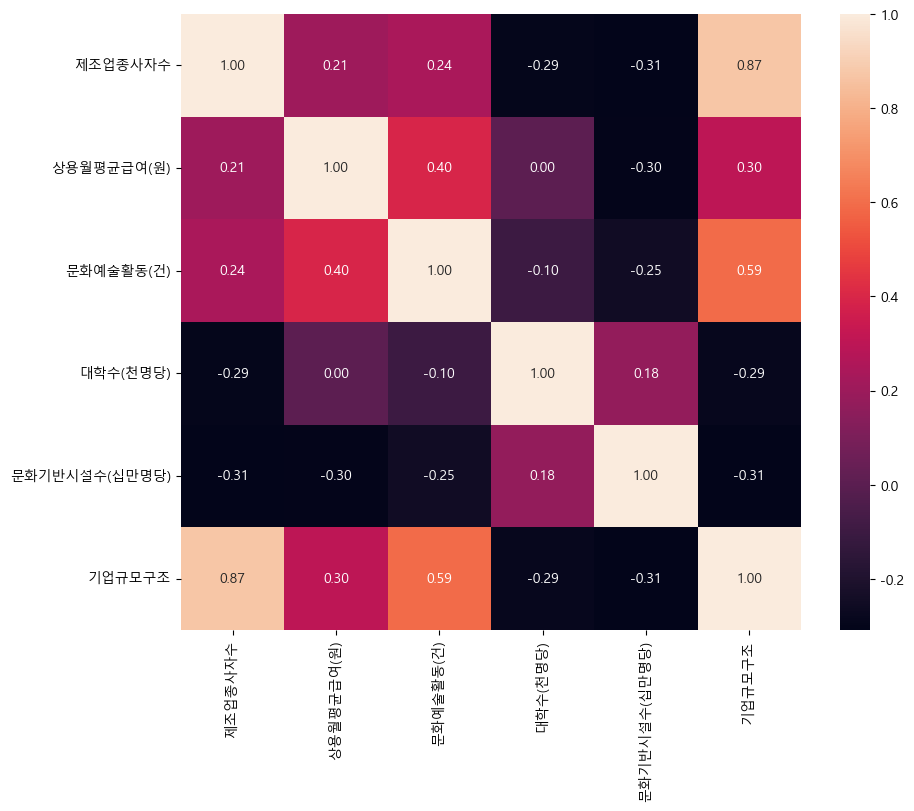

In [46]:
# 독립변수 상관관계 확인(다중공선성 문제 확인)
x_corr = x_cols.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(x_corr, annot=True, fmt=".2f")
plt.show()

In [47]:
# 1차 분산팽창계수 확인
X_scaled = StandardScaler().fit_transform(x_cols)
vif_df = pd.DataFrame()
vif_df['feature'] = x_cols.columns
vif_df['VIF'] = [
    variance_inflation_factor(X_scaled, i)
    for i in range(X_scaled.shape[1])
]

vif_df.sort_values('VIF', ascending=False)

,feature,VIF
5,기업규모구조,12.105955
0,제조업종사자수,8.551690
2,문화예술활동(건),3.331428
1,상용월평균급여(원),1.273737
4,문화기반시설수(십만명당),1.221441
3,대학수(천명당),1.123544


In [48]:
# 기업규모구조 = 제조업 규모 + 산업 집적 + 활동량을 거의 대리하는 변수 
# 기업규모구조와 제조업종사자수 -> 분산팽창계수 높음
# 제조업종사자수 삭제

merged = merged.drop(columns=['제조업종사자수'])

In [49]:
# 2차 변수 분류
# 종속변수
y_cols = merged[['청년_19_29_증감률(%)', '청년_30_39_증감률(%)']]

# 독립변수
x_cols = merged[['상용월평균급여(원)', '문화예술활동(건)', 
                '대학수(천명당)', '문화기반시설수(십만명당)', '기업규모구조']]

# 모델링용 독립변수
x_cols_control = merged[['상용월평균급여(원)', '문화예술활동(건)', 
                '대학수(천명당)', '문화기반시설수(십만명당)', '기업규모구조', '통계방식변경']]


# 통제변수
meta_cols = merged[['연앙인구수(천명)', '재정자립도(%)', '지역내총생산(십억원)']]

# Group by
group_cols = merged[['연도', '행정구역']]

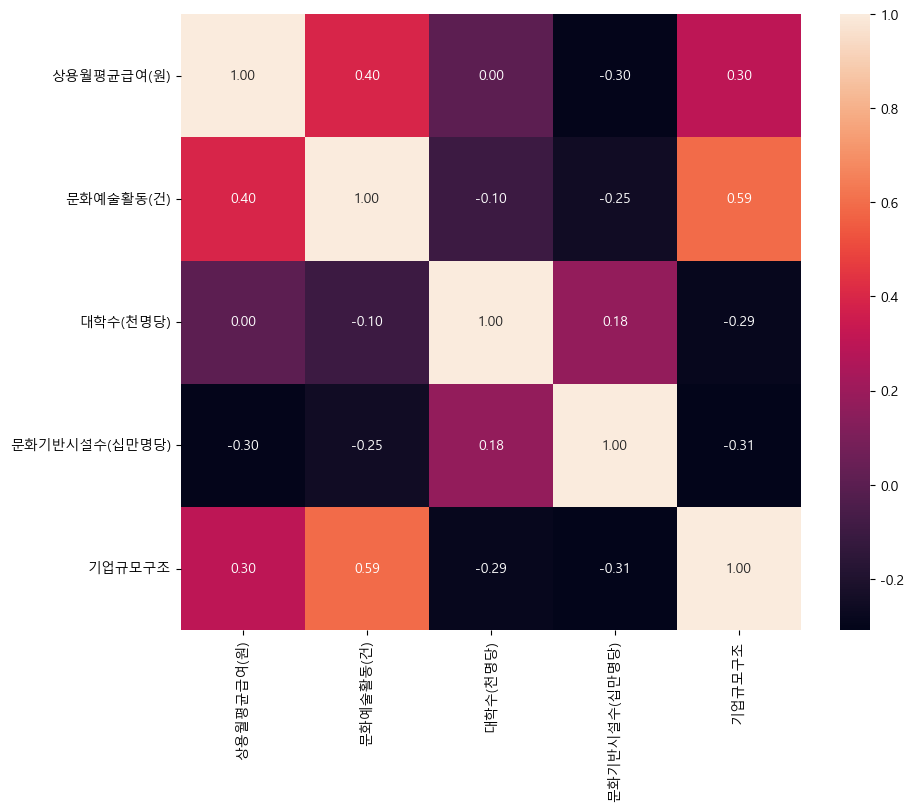

In [50]:
# 2차 독립변수 상관관계 확인(다중공선성 문제 확인)
x_corr = x_cols.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(x_corr, annot=True, fmt=".2f")
plt.show()

In [51]:
# 2차 분산팽창계수 확인
X_scaled = StandardScaler().fit_transform(x_cols)
vif_df = pd.DataFrame()
vif_df['feature'] = x_cols.columns
vif_df['VIF'] = [
    variance_inflation_factor(X_scaled, i)
    for i in range(X_scaled.shape[1])
]

vif_df.sort_values('VIF', ascending=False)

,feature,VIF
4,기업규모구조,1.735434
1,문화예술활동(건),1.680152
0,상용월평균급여(원),1.268429
3,문화기반시설수(십만명당),1.186180
2,대학수(천명당),1.122210


In [52]:
merged.to_csv('data/busan_youth_v4.csv')